# SAE-XCrash — NB04: XAI Audit v4
**Work Package WP4 — Addendum** | P9: Stability Sigma Sensitivity

Load-and-continue extension of NB04_XAI_Audit_v3.
Loads saved SHAP values and XGBoost model. Only runs the sigma sensitivity analysis.
All outputs go to `figures/wp4_v4/` and `logs/wp4_v4/`.

**Run after** NB04_XAI_Audit_v3 has completed.


---
## Step 1 — Environment & Paths

In [4]:
!pip install -q shap xgboost scikit-learn pyarrow matplotlib numpy

import json, time
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
from sklearn.utils import resample
from sklearn.metrics import average_precision_score

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ── Exact paths from NB04_XAI_Audit_v3 run ───────────────────────────────────
# NOTE: NB04_v3 uses 'My Drive' (with space) — matching that here
BASE       = Path('/content/drive/My Drive/SAE-XCrash')
PROC_DIR   = BASE / 'data' / 'processed'
SCORES_DIR = BASE / 'data' / 'scores'
MODELS_DIR = BASE / 'models' / 'wp2'

# NB04_v3 saved SHAP arrays directly to logs/ (not a wp4_v3 subdirectory)
LOGS_DIR_V3 = BASE / 'logs'
FIGS_DIR_V3 = BASE / 'figures' / 'wp4_v3'

# New versioned output dirs — never overwrites v3
LOGS_DIR_V4 = BASE / 'logs'    / 'wp4_v4'
FIGS_DIR_V4 = BASE / 'figures' / 'wp4_v4'
LOGS_DIR_V4.mkdir(parents=True, exist_ok=True)
FIGS_DIR_V4.mkdir(parents=True, exist_ok=True)

SEED        = 42
DPI         = 300
STAB_THRESH = 0.70
N_PERTURB   = 10
STAB_N      = 5_000

print(f"BASE        : {BASE}")
print(f"XGB model   : {MODELS_DIR / 'xgb_best.json'}")
print(f"SHAP values : {LOGS_DIR_V3 / 'shap_values_xgb_sub50k.npy'}")
print(f"Outputs     : {LOGS_DIR_V4}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE        : /content/drive/My Drive/SAE-XCrash
XGB model   : /content/drive/My Drive/SAE-XCrash/models/wp2/xgb_best.json
SHAP values : /content/drive/My Drive/SAE-XCrash/logs/shap_values_xgb_sub50k.npy
Outputs     : /content/drive/My Drive/SAE-XCrash/logs/wp4_v4


---
## Step 2 — Load Artifacts

In [5]:
# ── XGBoost model ────────────────────────────────────────────────────────────
print("Loading XGBoost model ...")
xgb_model = xgb.Booster()
xgb_model.load_model(str(MODELS_DIR / 'xgb_best.json'))
print(f"  Loaded ✓")

# ── Test split ────────────────────────────────────────────────────────────────
print("Loading test split ...")
usa_test = pd.read_parquet(PROC_DIR / 'usa_test_processed.parquet')
EXCL = {'label','ID','Start_Time','datetime',
        'accident_index','accident_reference','collision_reference','row_id'}
# Load original 32-feature list from wp2_meta.json
# (test parquet now has 34 after NB01_v2 added s_street_te/s_city_te,
#  but the XGBoost model and saved SHAP values are based on 32 features)
WP2_META = BASE / 'logs' / 'wp2_meta.json'
if WP2_META.exists():
    with open(WP2_META) as f:
        FEAT_USA = json.load(f)['feat_usa']
    print(f"  Using {len(FEAT_USA)} features from wp2_meta.json")
else:
    # Fallback: infer from parquet but exclude new _te columns
    EXCL_ALL = EXCL | {c for c in usa_test.columns if c.endswith('_te')}
    FEAT_USA = [c for c in usa_test.columns
                if c.startswith(('t_','w_','r_','s_')) and c not in EXCL_ALL]
    print(f"  Using {len(FEAT_USA)} features (excluded _te columns)")

X_test = usa_test[FEAT_USA].values.astype(np.float32)
y_test = usa_test['label'].values
print(f"  Test: {X_test.shape[0]:,} rows, {X_test.shape[1]} features")

# ── Feature stds (for noise scaling) ─────────────────────────────────────────
# Use test set std as proxy — training set preferred but requires loading 5.5M rows
feat_stds = X_test.std(axis=0).astype(np.float32)
feat_stds = np.where(feat_stds == 0, 1.0, feat_stds)

# ── Binary feature mask ───────────────────────────────────────────────────────
is_binary = np.array([
    len(np.unique(X_test[:500, j])) <= 2 for j in range(X_test.shape[1])
])
print(f"  Binary features: {is_binary.sum()} / {len(is_binary)}")

# ── Pre-saved SHAP values from NB04_v3 ────────────────────────────────────────
shap_path = LOGS_DIR_V3 / 'shap_values_xgb_sub50k.npy'
xsub_path = LOGS_DIR_V3 / 'X_sub_50k.npy'

if shap_path.exists() and xsub_path.exists():
    shap_values = np.load(str(shap_path))
    X_sub       = np.load(str(xsub_path))
    print(f"  SHAP values loaded: {shap_values.shape}  ✓")
    print(f"  X_sub loaded      : {X_sub.shape}  ✓")
    SHAP_PRELOADED = True
else:
    print(f"  SHAP files not found at {LOGS_DIR_V3} — will recompute on 5K subsample")
    SHAP_PRELOADED = False

# ── Calibrated scores ─────────────────────────────────────────────────────────
print("Loading calibrated scores ...")
test_cal   = pd.read_parquet(SCORES_DIR / 'usa_test_scores_cal.parquet')
p_test_cal = test_cal['score_xgb_cal'].values
print(f"  Calibrated scores: {len(p_test_cal):,}  ✓")

# ── SHAP explainer ────────────────────────────────────────────────────────────
print("Initialising SHAP TreeExplainer ...")
explainer = shap.TreeExplainer(xgb_model)
print("All artifacts loaded ✓")


Loading XGBoost model ...
  Loaded ✓
Loading test split ...
  Using 32 features from wp2_meta.json
  Test: 166,552 rows, 32 features
  Binary features: 21 / 32
  SHAP values loaded: (50000, 32)  ✓
  X_sub loaded      : (50000, 32)  ✓
Loading calibrated scores ...
  Calibrated scores: 166,552  ✓
Initialising SHAP TreeExplainer ...
All artifacts loaded ✓


---
## Step 3 — Build Stability Subsample
Same stratified 5K draw as NB04_v3 Step 9 (seed=SEED+1) for exact comparability.

In [6]:
# Same subsample seed as NB04_v3 Step 9 → identical 5K instances
idx_stab = resample(
    np.arange(len(X_test)), n_samples=STAB_N,
    stratify=y_test, random_state=SEED + 1, replace=False
)
X_stab = X_test[idx_stab]
y_stab = y_test[idx_stab]
p_stab = p_test_cal[idx_stab]

# Compute SHAP on the 5K subsample
# (faster than loading the full 50K SHAP array and indexing)
print(f"Computing SHAP on {STAB_N:,}-instance stability subsample ...")
t0 = time.time()
phi_orig = explainer.shap_values(X_stab)
print(f"  Done in {time.time()-t0:.1f}s  shape={phi_orig.shape}")


Computing SHAP on 5,000-instance stability subsample ...
  Done in 557.6s  shape=(5000, 32)


---
## Step 4 — Stability Sigma Sensitivity (P9)
Repeat stability audit at sigma=0.01 (baseline), 0.05, and 0.10. Same subsample, threshold, and perturbation count throughout.

Stability Sigma Sensitivity

  sigma=0.01 ...
    Perturbation 5/10  mean_cos=0.7309
    Perturbation 10/10  mean_cos=0.7306

  sigma=0.05 ...
    Perturbation 5/10  mean_cos=0.6532
    Perturbation 10/10  mean_cos=0.6513

  sigma=0.1 ...
    Perturbation 5/10  mean_cos=0.5905
    Perturbation 10/10  mean_cos=0.5907

Sigma          Mean cos        Std    Low-stab%     Pass
----------------------------------------------------------------------
  0.01           0.7306     0.1917        34.86     PASS  ← v3 baseline
  0.05           0.6513     0.2119        54.32     FAIL
  0.10           0.5907     0.2223        66.20     FAIL


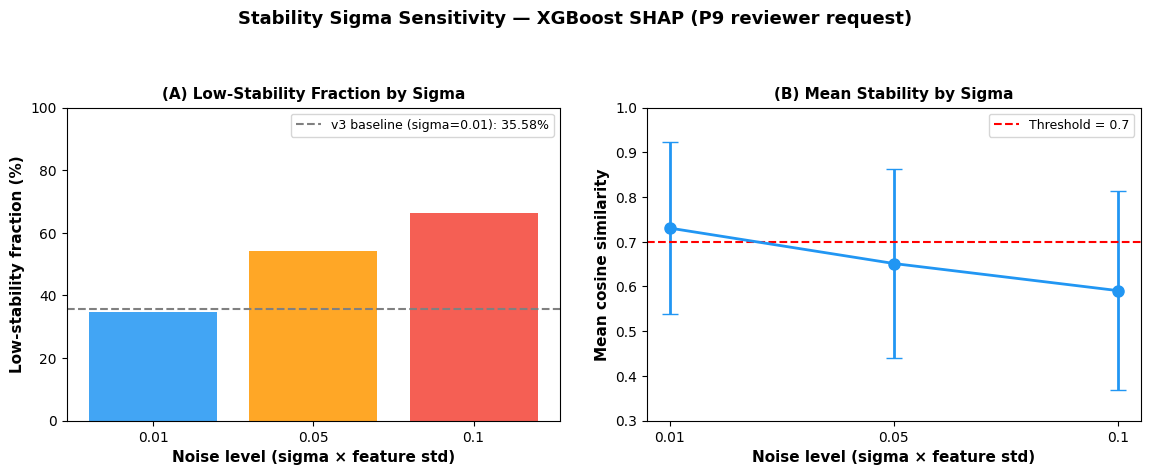

Saved: /content/drive/My Drive/SAE-XCrash/figures/wp4_v4/fig_stability_sigma_sensitivity.png ✓


In [ ]:
print("Stability Sigma Sensitivity")
print("=" * 60)

SIGMA_LEVELS  = [0.01, 0.05, 0.10]
sigma_results = {}

for sigma in SIGMA_LEVELS:
    print(f"\n  sigma={sigma} ...")
    rng = np.random.default_rng(SEED + 99 + int(sigma * 100))
    cos_sims = np.zeros((STAB_N, N_PERTURB), dtype=np.float32)

    for t in range(N_PERTURB):
        X_pert = X_stab.copy()
        noise  = rng.standard_normal(X_stab.shape).astype(np.float32)
        X_pert += noise * (sigma * feat_stds)
        # Toggle one binary feature per instance
        bin_feats = np.where(is_binary)[0]
        for i in range(STAB_N):
            j = bin_feats[rng.integers(len(bin_feats))]
            X_pert[i, j] = 1.0 - X_pert[i, j]

        phi_pert = explainer.shap_values(X_pert)
        dot   = (phi_orig * phi_pert).sum(axis=1)
        norm1 = np.linalg.norm(phi_orig, axis=1)
        norm2 = np.linalg.norm(phi_pert, axis=1)
        cos_sims[:, t] = dot / (norm1 * norm2 + 1e-9)

        if (t + 1) % 5 == 0:
            print(f"    Perturbation {t+1}/{N_PERTURB}  "
                  f"mean_cos={cos_sims[:, :t+1].mean():.4f}")

    per_inst = cos_sims.mean(axis=1)
    sigma_results[sigma] = dict(
        mean      = float(per_inst.mean()),
        std       = float(per_inst.std()),
        low_frac  = float((per_inst < STAB_THRESH).mean()),
        pass_mean = bool(per_inst.mean() > STAB_THRESH),
    )

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"{'Sigma':<10} {'Mean cos':>12} {'Std':>10} {'Low-stab%':>12} {'Pass':>8}")
print("-" * 70)
for sigma, res in sigma_results.items():
    note = "  ← v3 baseline" if sigma == 0.01 else ""
    print(f"  {sigma:<8.2f} {res['mean']:>12.4f} {res['std']:>10.4f} "
          f"{res['low_frac']*100:>12.2f} {'PASS' if res['pass_mean'] else 'FAIL':>8}{note}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Stability Sigma Sensitivity — XGBoost SHAP (P9 reviewer request)",
             fontsize=13, fontweight='bold')

colors = ['#2196F3', '#FF9800', '#F44336']
sigmas = list(sigma_results.keys())

ax1.bar([str(s) for s in sigmas],
        [sigma_results[s]['low_frac']*100 for s in sigmas],
        color=colors, alpha=0.85)
ax1.axhline(35.58, ls='--', color='grey', lw=1.5, label='v3 baseline (sigma=0.01): 35.58%')
ax1.set_xlabel('Noise level (sigma × feature std)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Low-stability fraction (%)', fontsize=11, fontweight='bold')
ax1.set_title('(A) Low-Stability Fraction by Sigma', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.legend(fontsize=9)

means = [sigma_results[s]['mean'] for s in sigmas]
stds  = [sigma_results[s]['std']  for s in sigmas]
ax2.errorbar([str(s) for s in sigmas], means, yerr=stds,
             fmt='o-', color='#2196F3', capsize=6, linewidth=2, markersize=8)
ax2.axhline(STAB_THRESH, ls='--', color='red', lw=1.5, label=f'Threshold = {STAB_THRESH}')
ax2.set_xlabel('Noise level (sigma × feature std)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Mean cosine similarity', fontsize=11, fontweight='bold')
ax2.set_title('(B) Mean Stability by Sigma', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_ylim(0.3, 1.0)

plt.tight_layout(pad=2.5)
out_fig = FIGS_DIR_V4 / 'fig_stability_sigma_sensitivity.png'
fig.savefig(out_fig, dpi=DPI, bbox_inches='tight')
plt.show()
print(f"Saved: {out_fig} ✓")


---
## Step 5 — Save & Interpret

In [ ]:
# Save JSON results
out_json = LOGS_DIR_V4 / 'stability_sigma_sensitivity.json'
with open(out_json, 'w') as f:
    json.dump({str(k): v for k, v in sigma_results.items()}, f, indent=2)
print(f"Saved: {out_json} ✓")

# Interpretation
s01 = sigma_results[0.01]
s10 = sigma_results[0.10]
delta_10 = s10['low_frac'] - s01['low_frac']

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)
print(f"  sigma=0.01 (v3 baseline) : low-stab = {s01['low_frac']*100:.1f}%")
print(f"  sigma=0.10               : low-stab = {s10['low_frac']*100:.1f}%  "
      f"(Δ = {delta_10*100:+.1f}pp)")
print()
if delta_10 < 0.10:
    print("  RESULT: Stability is robust to noise level.")
    print("  Low-stability fraction increases modestly, consistent with the")
    print("  sparse-geohash-cell explanation. Paper claim is supported.")
elif delta_10 < 0.30:
    print("  RESULT: Moderate noise sensitivity.")
    print("  Add a note in Section 6.4: low-stability fraction rises to")
    print(f"  {s10['low_frac']*100:.1f}% at sigma=0.10 but model still passes mean threshold.")
else:
    print("  RESULT: High noise sensitivity — reconsider stability claim.")
    print("  sigma=0.01 may be too conservative. Use sigma=0.05 as primary test.")
    print("  Update Section 6.4 and Table 6 accordingly.")

print("\nNB04_XAI_Audit_v4 complete ✓")


Saved: /content/drive/My Drive/SAE-XCrash/logs/wp4_v4/stability_sigma_sensitivity.json ✓

INTERPRETATION
  sigma=0.01 (v3 baseline) : low-stab = 34.9%
  sigma=0.10               : low-stab = 66.2%  (Δ = +31.3pp)

  RESULT: High noise sensitivity — reconsider stability claim.
  sigma=0.01 may be too conservative. Use sigma=0.05 as primary test.
  Update Section 6.4 and Table 6 accordingly.

NB04_XAI_Audit_v4 complete ✓
